Notes: 

cell builder is currently embedded in the simulation module... Need to build the 

Also want to implement new clustering method...

In [1]:
import sys
sys.path.append('..')
sys.path.append('../Modules')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
print(os.getcwd())
if 'notebook' in os.getcwd():
    # os.chdir("../scripts") # go from Neural-Modeling/notebooks to Neural-Modeling/scripts, where simulation outputs will be generated to. (maybe a separate folder could be used...)
    os.chdir("../simulations") # go to output folder
    print(os.getcwd())

/home/drfrbc/Neural-Modeling/notebooks
/home/drfrbc/Neural-Modeling/simulations


User Specifications -  get parameters, simulation folder

In [2]:
from Modules.constants import HayParameters
import datetime
import pickle
from neuron import h

from Modules.simulation_slurm import Simulator

# this is a quick example, but the generation of parameter sets and titles for parametric study is in scripts/gen_param_list_advanced.py

sim_set_title="description_of_simulation_set"
sim_titles = ["description_of_simulation1_within_set"] # for multiple: ["description_of_simulation1_within_set", "description_of_simulation2_within_set"],
parameter_sets = [HayParameters(sim_title, all_synapses_off=True) for sim_title in sim_titles] # no variation between simulations with this code snippet
# initialize with all_synapses_off for saving segments.csv without building synapses.
# TODO: 

simulator = Simulator(
                        sim_set_title = sim_set_title,
                        sim_titles = sim_titles,
                        parameter_sets = parameter_sets)

# create simulation folders and save parameters in them
simulator.create_simulation_folders()

# @TODO: modularize gen_param_list_advanced.py so it can optionally be used here.
# @TODO: compile modfiles once in Simulator.__init__ if not already compiled. would need to specify them.
# @TODO: at simulation time, the parameters should be loaded from each sim_dir in sims_dir. 

--No graphics will be displayed.


Mod files loaded successfully


Build cell to save segments csv

In [3]:
simulator.sims_dir

'2025-04-25-17-01-description_of_simulation_set'

In [4]:
from Modules.segments_file import generate_segments_csv

simulator.run_on_all_sims(simulator.sims_dir, generate_segments_csv) # generate the segments csv for each simulation

Removing duplicate coordinate at index 1 in section L5PCtemplate[0].apic[0]
getting segments of types: ['distal_basal' 'nexus' 'oblique' 'perisomatic' 'trunk' 'tuft'] for synapses


Visualize precise section typing

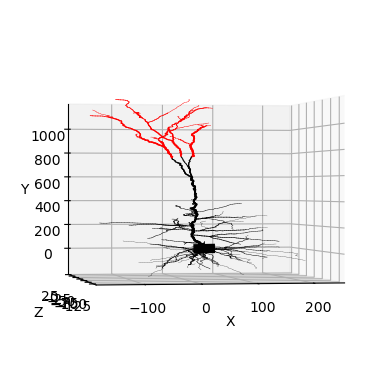

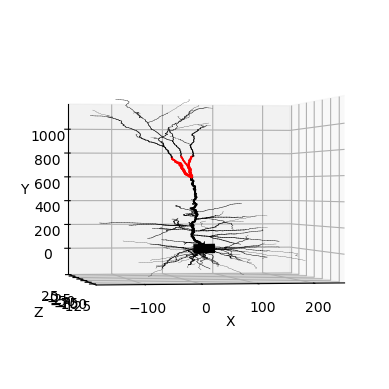

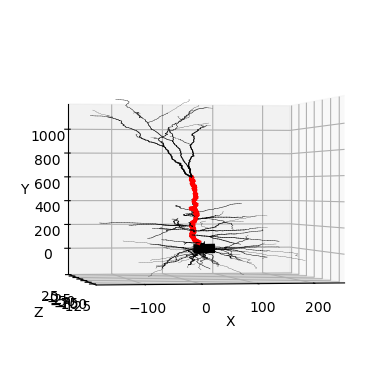

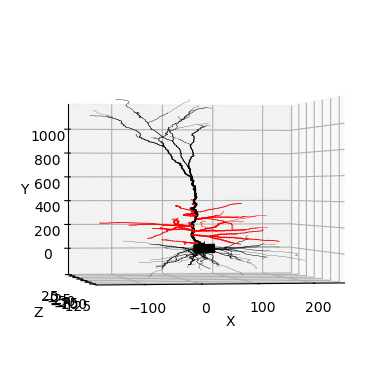

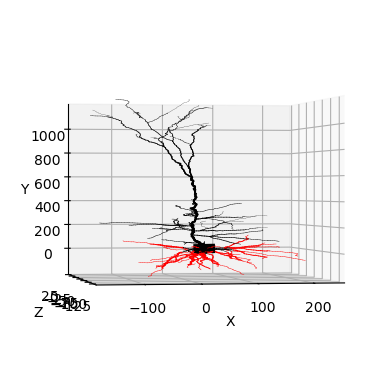

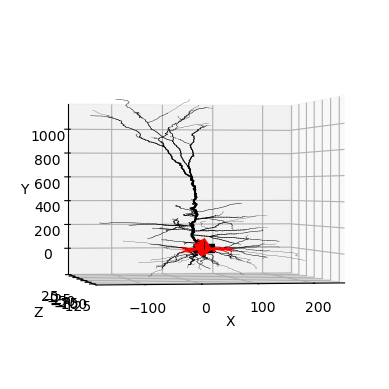

In [ ]:
# for visualizing the cell
# also for debugging sec_type_precise generation by viewing selected segments
from Modules.plot_morphology import plot_morphology_with_highlighted_sec_type

sim_dir = os.path.join(simulator.sims_dir, simulator.sim_titles[0])

with open(os.path.join(sim_dir, "parameters.pickle"), "rb") as f: # load parameters
                parameters = pickle.load(f)

seg_data = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))


os.makedirs(os.path.join(sim_dir, "morphology"), exist_ok=True)
for sec_type in parameters.inh_syn_properties.keys(): # get list of section types
    fig, ax = plot_morphology_with_highlighted_sec_type(sec_type, seg_data)
    ax.set_title(sec_type) # TODO: not working for some reason
    fig.tight_layout()
    plt.show()
    fig.savefig(os.path.join(sim_dir, "morphology", f"{sec_type}.png"))


### OVERLAPPING PRECISE SEC TYPE LABELS TODO: (pull from generate_segments_csv)
# overlapping_seg_ids = [i for i,j in overlaps.items()]


Generate synapses in csv

In [6]:
# generate synapse objects abstractly. store info in csv.
from Modules.synapses_file import PreSimSynapseGenerator
from functools import partial

def use_pssg(sim_dir: str,  pssg_function_name):
    # create PreSimSynapseGenerator instance
    pssg = PreSimSynapseGenerator(sim_dir)
    getattr(pssg, pssg_function_name)()
    pssg.synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)
    # return pssg 

# create PreSimSynapseGenerator instance
pssg = PreSimSynapseGenerator(sim_dir)
pssg.generate_synapse_locations()
pssg.synapses.to_csv(os.path.join(sim_dir, "synapses.csv"), index=False)
# return pssg 

# simulator.run_on_all_sims(simulator.sims_dir, use_pssg)

In [7]:
# # view synapses from synapses csv
synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
# synapses # show the synapses

In [8]:
segments = pd.read_csv(os.path.join(sim_dir, "segment_data.csv"))
# segments # show the segments

Generate Spike Trains and add to csv

In [9]:
# adds column spike_train according to parameters.
pssg.generate_spike_trains_for_synapses()
# simulator.run_on_all_sims(simulator.sims_dir, use_pssg, pssg_function_name= 'generate_spike_trains_for_synapses') #TODO: fix

In [10]:
# # view update to include spike_train column in snyapses csv
# synapses = pd.read_csv(os.path.join(sim_dir, "synapses.csv"))
# synapses # show the csv

Read synapse specifications and build cell with synapses

In [11]:
pssg = PreSimSynapseGenerator(sim_dir)
cell = pssg.build_synapses_onto_cell_obj() # TODO: Run on all simulations implementation

Removing duplicate coordinate at index 1 in section L5PCtemplate[0].apic[0]


Simulate

In [12]:
from Modules.simulation_slurm import Simulation
from Modules.cell_builder import SkeletonCell
from Modules.logger import Logger

sim = Simulation(getattr(SkeletonCell, parameters.skeleton_cell_type)) #TODO: clean up implementation. Probably creating extra folder.
sim.path = simulator.sims_dir
sim.logger = Logger(sim_dir)

sim.run_single_simulation(parameters=parameters, cell=cell)

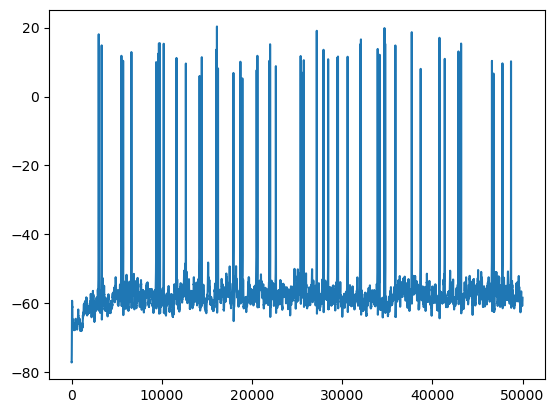

In [13]:
import Modules.analysis as analysis
v = analysis.DataReader.read_data(sim_dir, 'v')
plt.plot(v[0,:])